In [91]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import sys

import main as lightcode
import hardware as hw
import graph_transformations as gt
import stacked_graph as sg
import input_validation as validate
import data_collection as dc
import code_generation as cg
import graph_visualization as gv
import models

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [92]:

# optimization = "time"
optimization = "energy"
# optimization = "always_phu"

CPU_MAX_CLOCK = 5.0875 * 10**9  # 5.0875 e+9 5Ghz
CPU_AVERAGE_CLOCK = 3.208 * 10**9  # 60**9, 6
PHU_MIN_CLOCK = 9.7 * 10**9  # 100**9, 10 Ghz

hardware = []
hw.Hardware._hardware_reset()
hardware.append(hw.CPU(CPU_AVERAGE_CLOCK, 1))
hardware.append(hw.PHU(PHU_MIN_CLOCK, 1, 20))

available_hardware = hw.initilize_hardware(hardware)
subgraph_idx  = 4

ans = lightcode.graph_search_debug(
    models.llama_prefill,
    optimization,
    available_hardware,
    moc_sequence_length = 3500,
    subgraph = subgraph_idx,
    profiles=True,
    data_collection=True,
)

subgraph = ans

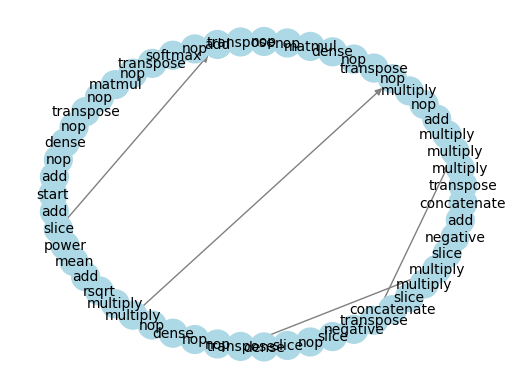

In [93]:
fig, ax = plt.subplots()

gv.adj_to_graph(
    subgraph,
    ax,
    save=False,
    layout="shell",
    title=f"Graph {subgraph_idx} with {len(subgraph)} nodes",
    stack=True,
)

plt.show()

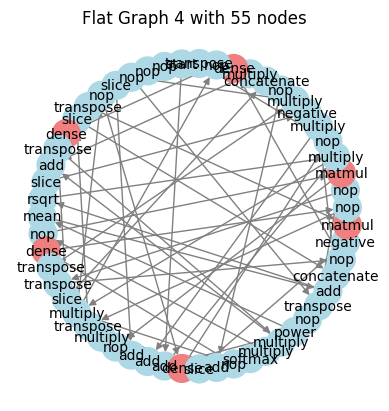

In [94]:
flat_subgraphs = gt.pathfinding_node_selection([subgraph], weight_variable=optimization)
flat_subgraph = flat_subgraphs[0]

fig, ax = plt.subplots()

gv.adj_to_graph(
    flat_subgraph,
    ax,
    save=False,
    layout="shell",
    title=f"Flat Graph {subgraph_idx} with {len(flat_subgraph)} nodes",
    stack=False,
)

plt.show()

In [95]:
energy_data, delta_energy, total_energy = dc.get_energy_profile(flat_subgraph)
print(len(flat_subgraph))
print(f'optimization {optimization:<12}: {total_energy} pj')

55
optimization energy      : 93287466177.6 pj


In [96]:
expanded_flat_subgraphs = gt.expand_nodes(flat_subgraphs)
expanded_flat_subgraph = expanded_flat_subgraphs[0]

print(len(expanded_flat_subgraph))

energy_data, delta_energy, total_energy = dc.get_energy_profile(expanded_flat_subgraph)
print(f'optimization {optimization:<12} expanded: {total_energy} pj')

129
optimization energy       expanded: 217231361229.5 pj
